## DATA PREPROCESSING

### This HR dataset contains over 150 employee records with intentional data quality issues, including; 
### missing values, duplicate rows and columns, incorrect data types, outliers, and 
### an unnecessary ID variable for data cleaning practice.

## Data importation

In [2]:
import pandas as pd
data=pd.read_excel("messy_dataset.xlsx")
data.head()

,ID,Age,Gender,Income,Department,Years_Experience,Performance_Score,Join_Date,Bonus,Income.1
0,1,30.0,Female,44176.034015,NaN,26,4,2010-01-31,5519.445003,44176.034015
1,2,46.0,Male,50000.000000,IT,9,2,2010-02-28,3191.366750,36717.314393
2,3,32.0,Male,1000000.000000,IT,25,3,2010-03-31,6277.184918,44648.824613
3,4,150.0,Male,58341.826978,Finance,18,1,2010-04-30,1676.959875,58341.826978
4,5,25.0,Male,65657.909164,HR,38,5,2010-05-31,4867.840403,65657.909164


### The dataset was successfully imported from the Excel file into the analysis environment (jupyter notebook)
### Viewing the first few rows (using `head()`) revealed missing values, duplicated columns, inconsistent entries 
### and unusually large values, confirming the dataset requires cleaning before analysis.


# Address Missing Values

### Identify and quantify missing values across all columns. 
### Based on the findings, strategize and apply appropriate methods to handle them (imputation, removal, or marking).

## Check total missing values in each column

In [3]:
print(data.isnull().sum())

ID                    0
Age                  10
Gender                0
Income               11
Department           11
Years_Experience      0
Performance_Score     0
Join_Date             0
Bonus                 0
Income.1             11
dtype: int64


## Check total missing values in the entire dataset

In [4]:
print("Total missing values:", data.isnull().sum().sum())

Total missing values: 43


## Display rows that contain missing values

In [5]:
print(data[data.isnull().any(axis=1)])

      ID   Age  Gender        Income Department  Years_Experience  \
0      1  30.0  Female  44176.034015        NaN                26   
12    13   NaN    Male  69490.952214         HR                 0   
14    15  41.0  Female  59264.612683        NaN                12   
21    22  55.0    Male           NaN         HR                20   
26    27  39.0  Female           NaN         HR                35   
27    28  61.0  Female           NaN    Finance                34   
42    43   NaN  Female  35554.765609         HR                15   
45    46  31.0    Male  47940.922744        NaN                11   
49    50   NaN  Female           NaN         HR                27   
60    61   NaN    Male  65861.352633  Marketing                32   
62    63  19.0  Female           NaN         HR                12   
63    64  23.0  Female  65992.978161        NaN                27   
74    75  48.0  Female           NaN    Finance                 4   
78    79   NaN    Male  32711.5194

## Separate numerical and categorical columns

In [6]:
print(data.dtypes)

ID                            int64
Age                         float64
Gender                          str
Income                      float64
Department                      str
Years_Experience              int64
Performance_Score             int64
Join_Date            datetime64[us]
Bonus                       float64
Income.1                    float64
dtype: object


In [7]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object','str']).columns

## Impute numerical columns with mean

In [8]:
for col in num_cols:
    data[col] = data[col].fillna(data[col].mean())

## Impute categorical columns with mode

In [9]:
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

## Check if missing values remain

In [10]:
print(data.isnull().sum())

ID                   0
Age                  0
Gender               0
Income               0
Department           0
Years_Experience     0
Performance_Score    0
Join_Date            0
Bonus                0
Income.1             0
dtype: int64


## Identify and remove duplicates and unnecessary factors

## Identify Duplicate Rows

In [11]:
duplicate_rows = data[data.duplicated()]
print("Number of duplicate rows:", duplicate_rows.shape[0])

Number of duplicate rows: 5


## Identify Duplicate Columns

In [12]:
duplicate_columns = data.columns[data.T.duplicated()]
print("Duplicate columns:", list(duplicate_columns))

Duplicate columns: []


In [13]:
datta = data.rename(columns={
    "Income.1": "Income"})
datta.head()

,ID,Age,Gender,Income,Department,Years_Experience,Performance_Score,Join_Date,Bonus,Income
0,1,30.0,Female,44176.034015,HR,26,4,2010-01-31,5519.445003,44176.034015
1,2,46.0,Male,50000.000000,IT,9,2,2010-02-28,3191.366750,36717.314393
2,3,32.0,Male,1000000.000000,IT,25,3,2010-03-31,6277.184918,44648.824613
3,4,150.0,Male,58341.826978,Finance,18,1,2010-04-30,1676.959875,58341.826978
4,5,25.0,Male,65657.909164,HR,38,5,2010-05-31,4867.840403,65657.909164


In [14]:
duplicate_columns = datta.columns[datta.T.duplicated()]
print("Duplicate columns:", list(duplicate_columns))

Duplicate columns: []


## Remove Duplicate Rows

In [15]:
data = data.drop_duplicates()

## Remove Duplicate Columns

In [16]:
data = data.loc[:, ~data.T.duplicated()]

## Drop Unnecessary Variables (e.g., ID)

In [17]:
data = data.drop(columns=["ID"], errors="ignore")

## Rename Variables

In [18]:
df = data.rename(columns={
    "Age": "Age"})

In [19]:
## View cleaned dataset structure

In [20]:
print(df.head())
print("\nFinal shape of dataset:", df.shape)

     Age  Gender          Income Department  Years_Experience  \
0   30.0  Female    44176.034015         HR                26   
1   46.0    Male    50000.000000         IT                 9   
2   32.0    Male  1000000.000000         IT                25   
3  150.0    Male    58341.826978    Finance                18   
4   25.0    Male    65657.909164         HR                38   

   Performance_Score  Join_Date        Bonus      Income.1  
0                  4 2010-01-31  5519.445003  44176.034015  
1                  2 2010-02-28  3191.366750  36717.314393  
2                  3 2010-03-31  6277.184918  44648.824613  
3                  1 2010-04-30  1676.959875  58341.826978  
4                  5 2010-05-31  4867.840403  65657.909164  

Final shape of dataset: (150, 9)


In [31]:
columns_to_drop=['Join_Date','Income.1']

## Outlier detection and removal

## Select numerical columns only

In [32]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

## Detect Outliers using IQR

In [33]:
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = outliers.shape[0]

print("Number of outliers per column:")
print(outlier_summary)

Number of outliers per column:
{'Age': 0, 'Income': 0, 'Years_Experience': 0, 'Performance_Score': 0, 'Bonus': 1}


## Remove Outliers

In [34]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("\nDataset shape after removing outliers:", df.shape)


Dataset shape after removing outliers: (143, 7)


## Boxplots (one per variable, no specific colors) 

In [35]:
import matplotlib.pyplot as plt

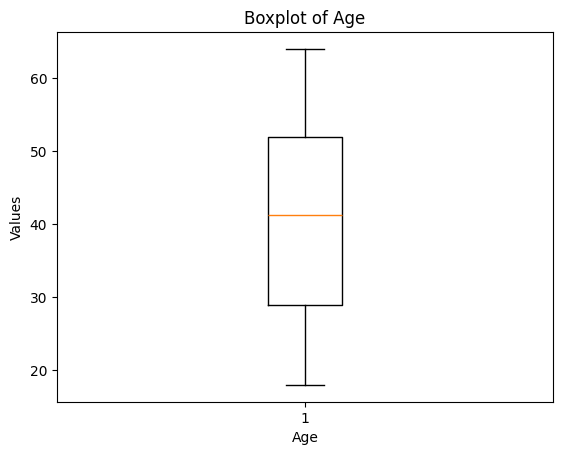

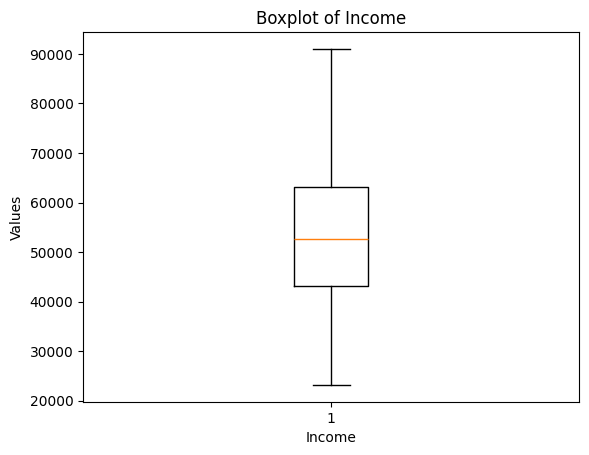

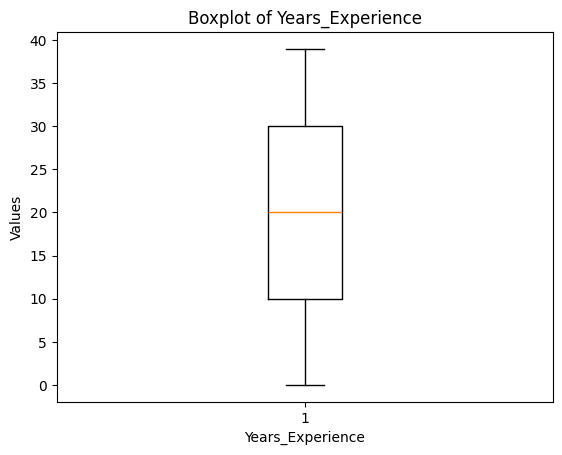

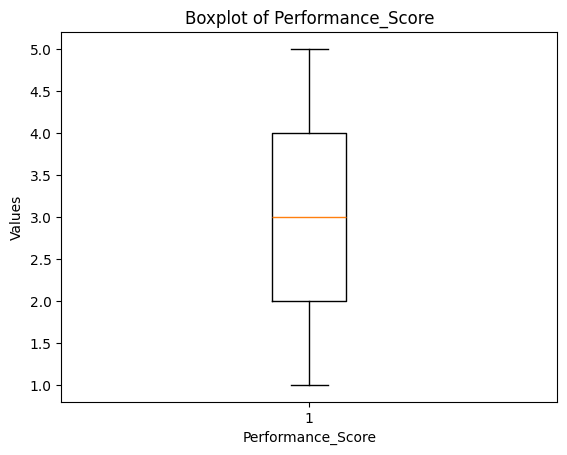

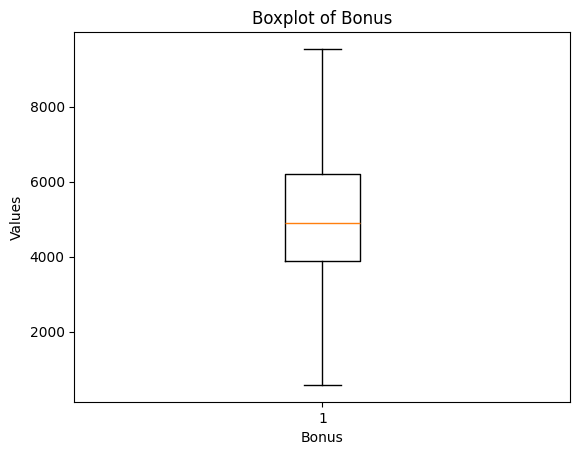

In [36]:
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.ylabel("Values")
    plt.show()

In [37]:
df.describe()

,Age,Income,Years_Experience,Performance_Score,Bonus
count,143.000000,143.000000,143.000000,143.000000,143.000000
mean,40.622860,53351.034892,19.727273,2.965035,4994.285292
std,13.575062,14400.331313,11.768412,1.396235,1879.912562
min,18.000000,23172.552425,0.000000,1.000000,577.729382
25%,29.000000,43122.560143,10.000000,2.000000,3879.479052
50%,41.206897,52642.713831,20.000000,3.000000,4891.410267
75%,52.000000,63227.480115,30.000000,4.000000,6209.853993
max,64.000000,91016.332386,39.000000,5.000000,9541.385716
